# Fragmentación de manuales

Comparación de siete configuraciones de fragmentación fija y recursiva, con distintos tamaños y solapamientos.

Este notebook solo lee resultados guardados. Ejecutar todas las celdas no descarga modelos, no consulta servicios y no sobrescribe las mediciones.

## Método y alcance

Se usan tres manuales sintéticos de Catan, Azul y Carcassonne, diez consultas y `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`. Los tamaños se expresan en caracteres. La fragmentación es la proporción de fragmentos que cortan una frase según la heurística del ejecutor. R@k y MRR evalúan la recuperación con los objetivos guardados en el JSON.

Los criterios fijados fueron R@3 ≥ 0,90, fragmentación ≤ 0,25 y consulta ≤ 50 ms. Se mantienen aunque ninguna configuración los cumpla todos.

In [1]:
import json
import sys
from pathlib import Path


sys.dont_write_bytecode = True


YELLOW = "\033[33m"


CYAN = "\033[36m"


GREEN = "\033[32m"


RESET = "\033[0m"


PALETTE = (
    "#89b4fa",
    "#cba6f7",
    "#f38ba8",
    "#b4befe",
    "#fab387",
    "#a6e3a1",
    "#f9e2af",
    "#94e2d5",
    "#74c7ec",
    "#eba0ac",
)


def info(text: str, highlight: object = "", after: str = "") -> None:
    """Resalta un dato y devuelve el resto del mensaje al cian."""
    message = text.rstrip(". ")
    if highlight != "":
        message += f" {GREEN}{highlight}{CYAN}"
    if after:
        message += f" {after.rstrip('. ')}"
    print(f"{YELLOW}[*]{RESET} {CYAN}{message}.{RESET}")


def read_json(path: Path) -> dict:
    with path.open(encoding="utf-8-sig") as stream:
        return json.load(stream)


def markdown_table(rows: list[dict], columns: dict[str, str]) -> str:
    from tabulate import tabulate

    return tabulate(
        [
            [
                f"{row[key]:.4f}".rstrip("0").rstrip(".")
                if isinstance(row[key], float)
                else row[key]
                for key in columns
            ]
            for row in rows
        ],
        headers=list(columns.values()),
        tablefmt="github",
        disable_numparse=True,
    )


def show_table(rows: list[dict], columns: dict[str, str]) -> None:
    from IPython.display import Markdown, display

    display(Markdown(markdown_table(rows, columns)))


def plot_metrics(rows: list[dict], metrics: list[tuple[str, str]], title: str):
    """Dos paneles horizontales para conservar etiquetas legibles."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    style = {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.edgecolor": "#bcc2cc",
        "axes.labelcolor": "#414654",
        "xtick.color": "#565e6d",
        "ytick.color": "#252a34",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "svg.fonttype": "none",
    }
    with mpl.rc_context(style):
        height = max(3.7, len(rows) * 0.42 + 1.4)
        figure, axes = plt.subplots(
            1,
            len(metrics),
            figsize=(13, height),
            layout="constrained",
            squeeze=False,
            sharey=True,
        )
        labels = [str(row["label"]) for row in rows]
        colors = [row.get("color", PALETTE[index % len(PALETTE)]) for index, row in enumerate(rows)]
        for axis, (key, caption) in zip(axes[0], metrics, strict=True):
            values = [row[key] for row in rows]
            bars = axis.barh(range(len(labels)), values, color=colors, height=0.64, zorder=3)
            axis.set_yticks(range(len(labels)), labels)
            axis.set_title(caption, loc="left")
            axis.set_axisbelow(True)
            axis.grid(axis="x", color="#e9ebef", linewidth=0.8)
            axis.tick_params(axis="y", length=0, pad=8)
            axis.margins(x=0.2)
            axis.bar_label(
                bars,
                labels=[f"{value:.3f}".rstrip("0").rstrip(".") for value in values],
                padding=5,
                fontsize=9,
            )
        axes[0, 0].set_ylim(len(labels) - 0.5, -0.5)
        figure.suptitle(title, fontsize=15, weight="bold", color="#252a34")
    plt.close(figure)
    return figure


relative = Path("rag/chunking")
here = Path.cwd().resolve()
benchmarks = next(
    parent / "docs/benchmarks"
    for parent in (here, *here.parents)
    if (parent / "docs/benchmarks" / relative / "results.json").is_file()
)

study = benchmarks / relative
data = read_json(study / "results.json")
info("Resultados guardados de", relative.as_posix(), "cargados")

rows = [dict(row, label=row["nombre"]) for row in data["resumen"]]

[*] Resultados guardados de rag/chunking cargados.


## Resultados

Los JSON conservan las mediciones originales.

### Recuperación y fragmentación

In [2]:
show_table(
    rows,
    {
        "label": "Configuración",
        "n_chunks": "Fragmentos",
        "frag": "Fragmentación ↓",
        "recall1": "R@1 ↑",
        "recall3": "R@3 ↑",
        "recall5": "R@5 ↑",
        "mrr": "MRR ↑",
        "q_ms": "Consulta ms",
    },
)

| Configuración   | Fragmentos   | Fragmentación ↓   | R@1 ↑   | R@3 ↑   | R@5 ↑   | MRR ↑   | Consulta ms   |
|-----------------|--------------|-------------------|---------|---------|---------|---------|---------------|
| fix-256-0       | 41           | 0.902             | 0.6     | 0.9     | 0.9     | 0.743   | 8.04          |
| fix-512-0       | 21           | 0.857             | 0.5     | 1       | 1       | 0.683   | 12.2          |
| fix-1024-0      | 11           | 0.818             | 0.6     | 0.9     | 1       | 0.758   | 10.59         |
| rec-256-0       | 74           | 0.649             | 0.5     | 0.7     | 1       | 0.637   | 9.22          |
| rec-512-0       | 28           | 0.607             | 0.5     | 0.9     | 1       | 0.675   | 7.47          |
| rec-512-64      | 28           | 0.607             | 0.5     | 0.8     | 0.9     | 0.681   | 8.1           |
| rec-1024-128    | 13           | 0.769             | 0.9     | 1       | 1       | 0.95    | 8.51          |

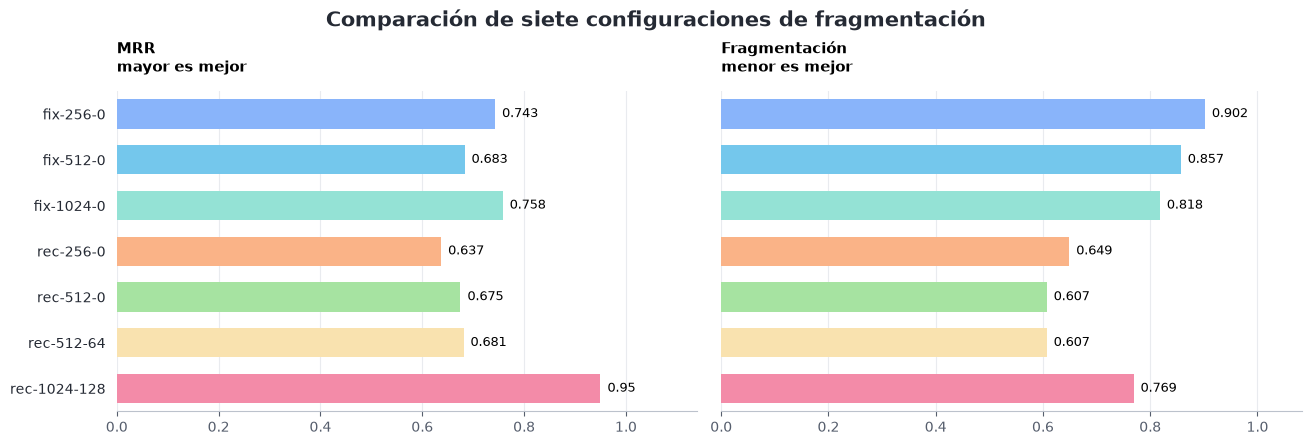

In [3]:
figure_0 = plot_metrics(
    rows,
    [("mrr", "MRR\nmayor es mejor"), ("frag", "Fragmentación\nmenor es mejor")],
    "Comparación de siete configuraciones de fragmentación",
)
figure_0

## Conclusiones

Ninguna configuración cumple todos los criterios. La división recursiva en
fragmentos de 1024 caracteres, con 128 de solapamiento, encuentra la respuesta
entre los tres primeros resultados en las diez consultas.

Sin embargo, corta frases en alrededor del 77 % de los fragmentos, muy por
encima del límite del 25 %. Recupera bien en este conjunto, pero no resuelve
el problema de fragmentación.

## Archivos y reproducción

`measure.py` conserva el método de medición y requiere una ejecución explícita con un directorio nuevo. Consulta el [índice](../../README.md) antes de medir. Las dependencias actuales no garantizan repetir exactamente el entorno histórico ni sus tiempos.